# 1. import liberaries

In [20]:
import pandas as pd
import numpy as np

In [18]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# 2. load cleaned dataset

In [10]:
df = pd.read_csv(
    "../data/processed/zomato_cleaned.csv"
)

print(df.head())

print("\nDataset Shape:", df.shape)

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table  rate  votes      location            rest_type  \
0          Yes        Yes   4.1    775  Banashankari        Casual Dining   
1          Yes         No   4.1    787  Banashankari        Casual Dining   
2          Yes         No   3.8    918  Banashankari  Cafe, Casual Dining   
3           No         No   3.7     88  Banashankari          Quick Bites   
4           No         No   3.8    166  Basavanagudi        Casual Dining   

                         cuisines  approx_cost(for two people)

# 3. select important columns 

In [11]:
df_model = df[[
    'online_order',
    'book_table',
    'votes',
    'location',
    'rest_type',
    'cuisines',
    'approx_cost(for two people)',
    'listed_in(type)',
    'rate'
]]

# 4. Handle missing values

In [12]:
encoder = LabelEncoder()

categorical_columns = [
    'online_order',
    'book_table',
    'location',
    'rest_type',
    'cuisines',
    'listed_in(type)'
]

for col in categorical_columns:

    df_model[col] = encoder.fit_transform(
        df_model[col]
    )

print("\nCategorical Columns Encoded")


Categorical Columns Encoded


# 6. Define features and target

In [13]:
X = df_model.drop('rate', axis=1)

y = df_model['rate']

# 7. train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)


Training Shape: (33010, 8)
Testing Shape: (8253, 8)


# 8. build model

In [15]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# 9. train model

In [21]:
model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


# 10. predictions

In [22]:
y_pred = model.predict(X_test)

# 11. evaluation

In [23]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print(f"\nMAE  : {mae}")

print(f"\nMSE  : {mse}")

print(f"\nRMSE : {rmse}")

print(f"\nR2 Score : {r2}")


========== MODEL PERFORMANCE ==========

MAE  : 0.051391415737139026

MSE  : 0.01307675076863814

RMSE : 0.11435362158077085

R2 Score : 0.9320427531917634


# 12. FEATURE IMPORTANCE

In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")

print(importance)


Feature Importance:

                       Feature  Importance
2                        votes    0.531342
5                     cuisines    0.161665
3                     location    0.113587
6  approx_cost(for two people)    0.093236
4                    rest_type    0.057714
1                   book_table    0.019095
0                 online_order    0.016803
7              listed_in(type)    0.006558


# 13. Visualize feature importance

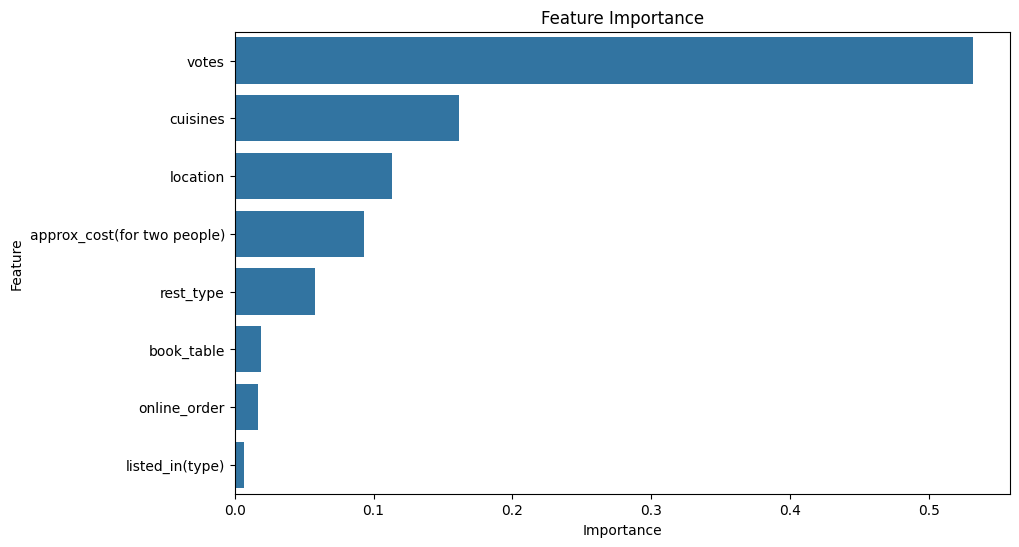

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

# 14. actual vs predicted

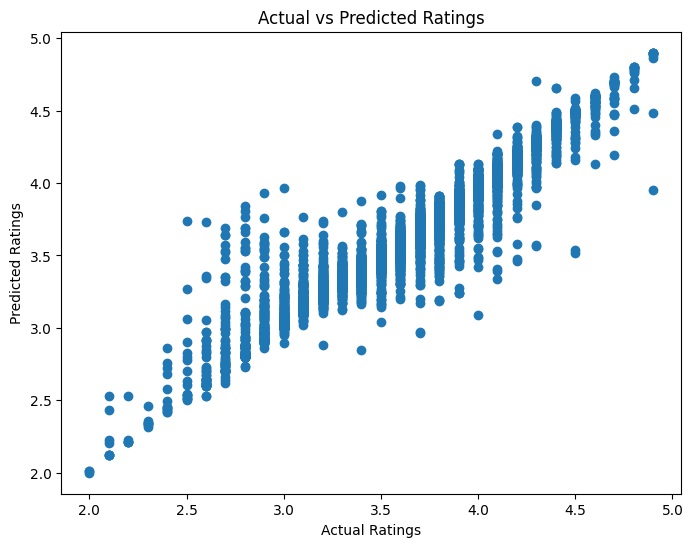

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

# 15. SAVE MODEL

In [29]:
import joblib
import os

os.makedirs("saved_model", exist_ok=True)

joblib.dump(
    model,
    "../models/zomato_rating_model.pkl"
)

print("\nModel Saved Successfully")


Model Saved Successfully
